# Telco Customer Churn — Exploratory Data Analysis

This notebook explores customer churn behavior using the processed Telco Customer Churn dataset.

The main objective is to identify patterns, relationships, and customer characteristics associated with churn.

## Analysis Goals

The exploratory analysis focuses on:

- Understanding churn distribution
- Exploring numerical feature distributions
- Investigating categorical variables
- Identifying relationships between features and churn
- Detecting potential correlations and behavioral patterns

## Key Questions

Some of the questions explored throughout this notebook include:

- Is the dataset balanced regarding churn?
- Do customers with short tenure churn more frequently?
- Does contract type affect churn behavior?
- Are higher monthly charges associated with churn?
- Do additional services such as Tech Support or Online Security reduce churn?

## Import section

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Load Interim Dataset

The dataset used in this notebook was previously cleaned and standardized during the data preparation stage

In [2]:
telco_churn = pd.read_parquet('data/interim/telco_churn_clean.parquet')

In [3]:
telco_churn.sample(5)

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6082,Female,0,Yes,No,59,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,101.099998,6039.899902,Yes
6325,Female,0,Yes,Yes,17,Yes,No,Fiber optic,Yes,No,No,Yes,Yes,No,Month-to-month,No,Electronic check,91.849998,1574.449951,Yes
702,Male,0,No,No,29,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.900002,2516.199951,No
1482,Female,1,No,No,13,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,96.849998,1235.550049,No
5403,Female,0,Yes,Yes,54,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,86.199997,4524.049805,No


## Visualization Settings

A consistent visual theme is applied across all plots to improve readability and maintain a clean analytical style.

In [4]:
sns.set_theme(style='ticks', palette='viridis', font='CMU Serif')

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titlepad'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelpad'] = 12


plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

plt.rcParams['legend.fontsize'] = 10

## Helper Functions

In [5]:
def add_percentage_labels(
	ax: plt.Axes, total: int = None, decimals: int = None
) -> None:
	"""
	Add percentage labels on top of bar plots.
	"""

	containers = ax.containers

	if total is None:
		total = sum(
			value for container in containers for value in container.datavalues
		)

	for container in containers:
		labels = [
			f'{(value / total) * 100:.{decimals}f}%'
			for value in container.datavalues
		]

		ax.bar_label(container, labels)


def add_normalized_percentage_labels(
	ax: plt.Axes, decimals: int = None
) -> None:
	"""
	Add normalized percentage labels per category.
	"""

	num_groups = len(ax.get_xticks())

	containers = ax.containers

	group_totals = []

	for i in range(num_groups):
		total = sum(container.datavalues[i] for container in containers)

		group_totals.append(total)

	for container in containers:
		labels = []

		for i, value in enumerate(container.datavalues):
			percentage = (value / group_totals[i]) * 100

			labels.append(f'{percentage:.{decimals}f}%')

		ax.bar_label(container, labels)

## Churn Distribution

Question:
How balanced is the churn distribution?

Goal:
Understand the proportion of churned and retained customers in the dataset and identify whether class imbalance may affect future modeling tasks.

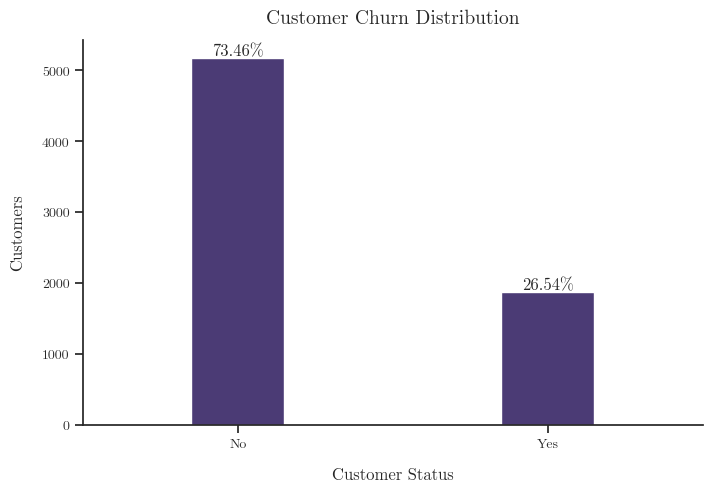

In [6]:
fig, ax = plt.subplots()

sns.countplot(
	data=telco_churn,
	x='Churn',
	width=0.3,
)

sns.despine()

ax.set_title('Customer Churn Distribution')

ax.set_xlabel('Customer Status')
ax.set_ylabel('Customers')

add_percentage_labels(ax, decimals=2)

plt.show()

## Customer Tenure Distribution

Question:
How long do customers typically stay with the company?

Goal:
Analyze the distribution of customer tenure to identify whether the dataset is composed mostly of new or long-term customers.

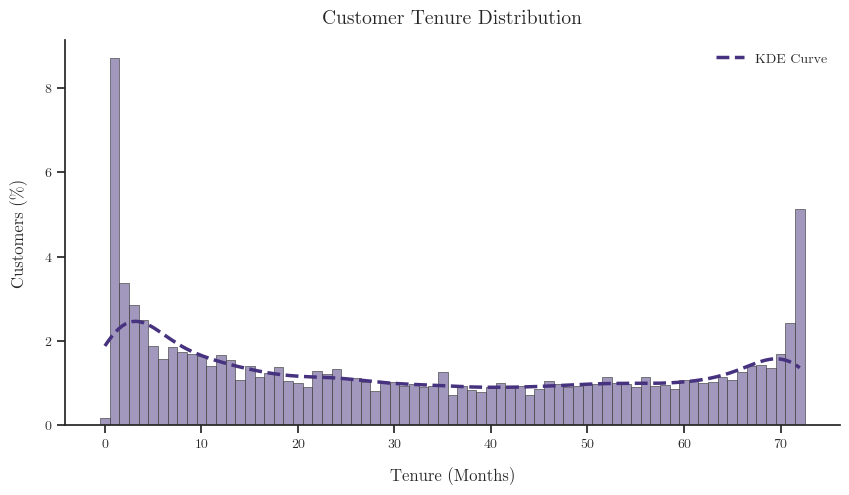

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
	data=telco_churn,
	x='Tenure',
	stat='percent',
	discrete=True,
	kde=True,
	edgecolor='.3',
	linewidth=0.5,
	kde_kws={'cut': 0, 'bw_adjust': 0.8},
	line_kws={'label': 'KDE Curve', 'linewidth': 2.5, 'linestyle': '--'},
	ax=ax,
)

sns.despine()

ax.set_title('Customer Tenure Distribution')

ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Customers (%)')

ax.legend(frameon=False)

plt.show()

## Monthly Charges Distribution

Question:
How are monthly charges distributed among customers?

Goal:
Investigate pricing distribution and detect whether customers are concentrated in lower-cost or premium plans.

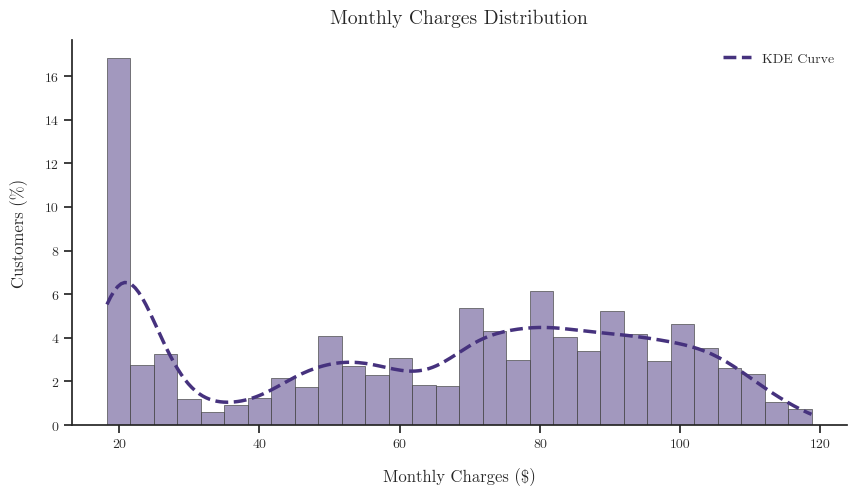

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
	data=telco_churn,
	x='MonthlyCharges',
	stat='percent',
	bins=30,
	kde=True,
	edgecolor='.3',
	linewidth=0.5,
	kde_kws={'cut': 0, 'bw_adjust': 0.8},
	line_kws={'label': 'KDE Curve', 'linewidth': 2.5, 'linestyle': '--'},
	ax=ax,
)

sns.despine()

ax.set_title('Monthly Charges Distribution')

ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Customers (%)')

ax.legend(frameon=False)

plt.show()

## Total Charges Distribution

Question:
How accumulated charges vary across customers?

Goal:
Understand how customer lifetime spending is distributed and identify potential asymmetries or long-tail behavior.

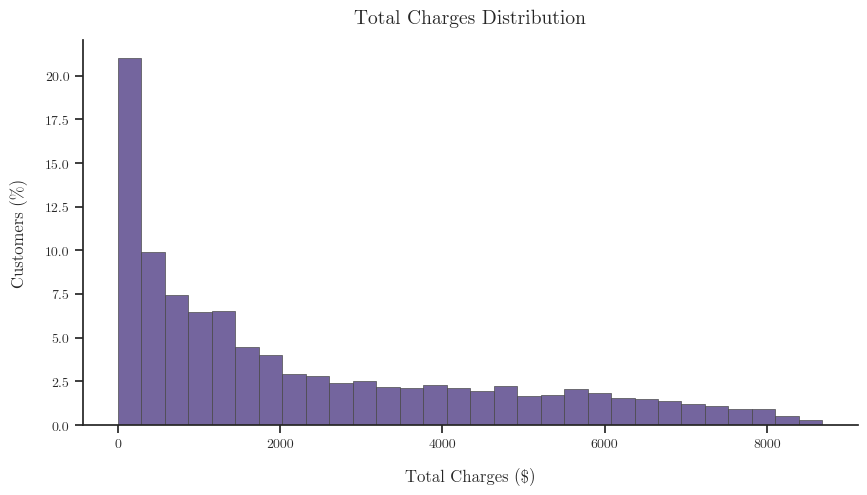

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
	data=telco_churn,
	x='TotalCharges',
	stat='percent',
	bins=30,
	edgecolor='.3',
	linewidth=0.5,
	ax=ax,
)

sns.despine()

ax.set_title('Total Charges Distribution')

ax.set_xlabel('Total Charges ($)')
ax.set_ylabel('Customers (%)')

plt.show()

## Contract Type vs Churn

Question:
Does contract type influence churn behavior?

Goal:
Investigate whether customers with short-term contracts are more likely to churn compared to customers with long-term contracts.

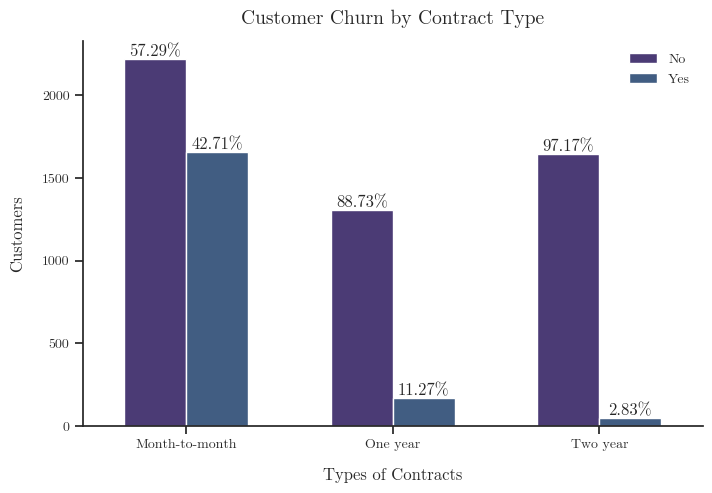

In [10]:
fig, ax = plt.subplots()

sns.countplot(data=telco_churn, x='Contract', hue='Churn', width=0.6)

sns.despine()

ax.set_title('Customer Churn by Contract Type')

ax.set_xlabel('Types of Contracts')
ax.set_ylabel('Customers')

ax.legend(frameon=False)

add_normalized_percentage_labels(ax, 2)

plt.show()

## Tenure vs Churn

Question:
Do newer customers churn more frequently?

Goal:
Analyze whether customer retention increases as tenure grows.

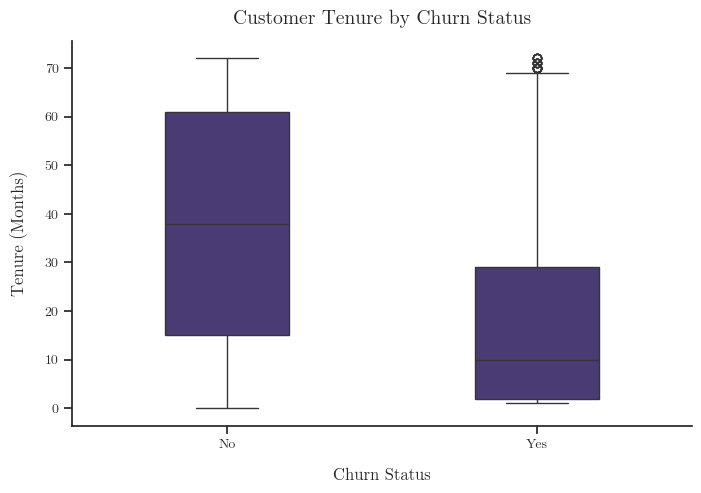

In [11]:
fig, ax = plt.subplots()

sns.boxplot(
	data=telco_churn,
	x='Churn',
	y='Tenure',
	width=0.4,
)

sns.despine()

ax.set_title('Customer Tenure by Churn Status')

ax.set_xlabel('Churn Status')
ax.set_ylabel('Tenure (Months)')

plt.show()

## Monthly Charges vs Churn

Question:
Do customers with higher monthly charges churn more frequently?

Goal:
Investigate whether pricing may influence churn behavior.

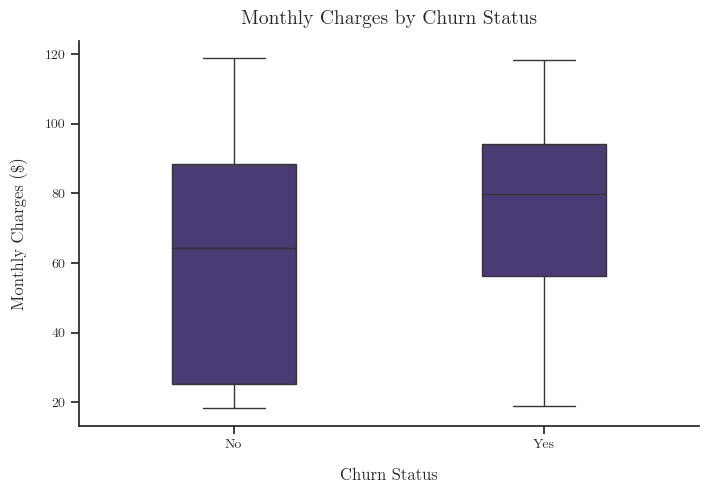

In [12]:
fig, ax = plt.subplots()

sns.boxplot(
	data=telco_churn,
	x='Churn',
	y='MonthlyCharges',
	width=0.4,
)

sns.despine()

ax.set_title('Monthly Charges by Churn Status')

ax.set_xlabel('Churn Status')
ax.set_ylabel('Monthly Charges ($)')

plt.show()

## Internet Service vs Churn

Question:
Does internet service type affect churn behavior?

Goal:
Analyze whether different internet service categories are associated with higher churn rates.

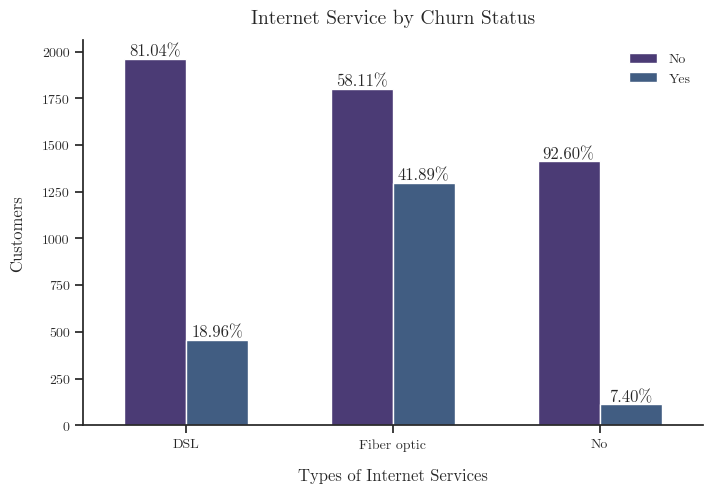

In [13]:
fig, ax = plt.subplots()

sns.countplot(
	data=telco_churn,
	x='InternetService',
	hue='Churn',
	width=0.6,
)

sns.despine()

ax.set_title('Internet Service by Churn Status')

ax.set_xlabel('Types of Internet Services')
ax.set_ylabel('Customers')

ax.legend(frameon=False)

add_normalized_percentage_labels(ax, 2)

plt.show()

## Online Security vs Churn

Question:
Are customers with online security services less likely to churn?

Goal:
Investigate whether additional security-related services improve customer retention.

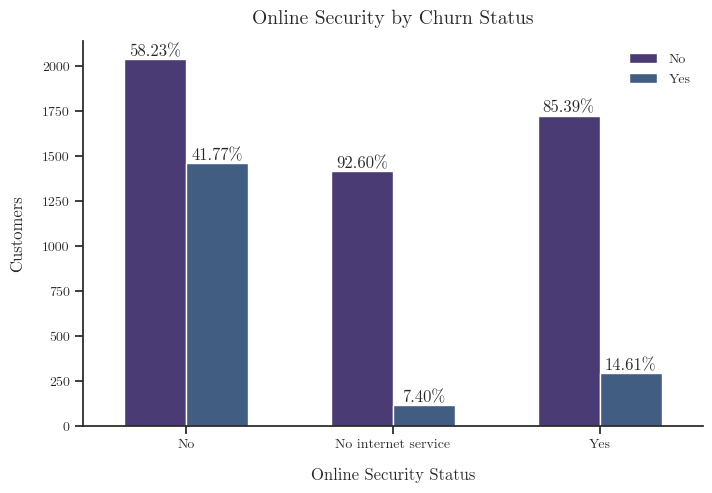

In [14]:
fig, ax = plt.subplots()

sns.countplot(
	data=telco_churn,
	x='OnlineSecurity',
	hue='Churn',
	width=0.6,
)

sns.despine()

ax.set_title('Online Security by Churn Status')

ax.set_xlabel('Online Security Status')
ax.set_ylabel('Customers')

ax.legend(frameon=False)

add_normalized_percentage_labels(ax, 2)

plt.show()

## Payment Method vs Churn

Question:
Do payment methods correlate with customer churn?

Goal:
Identify whether certain payment methods are associated with higher churn frequency.

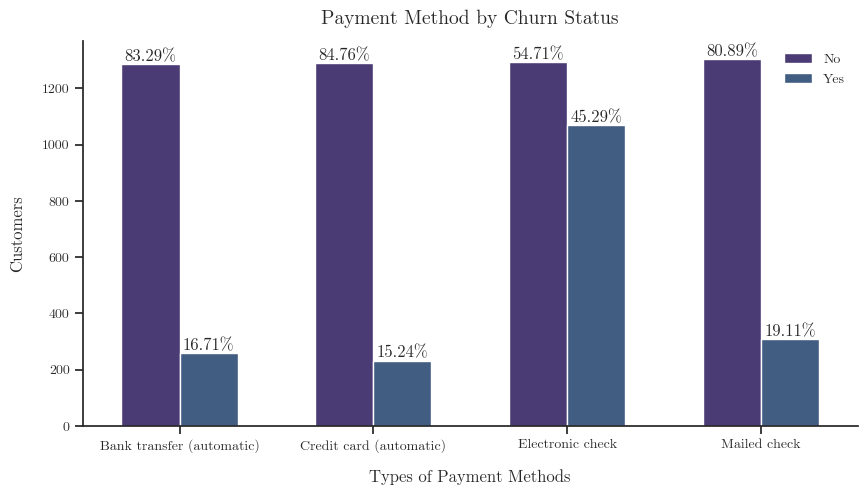

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.countplot(
	data=telco_churn, x='PaymentMethod', hue='Churn', width=0.6, ax=ax
)

sns.despine()

ax.set_title('Payment Method by Churn Status')

ax.set_xlabel('Types of Payment Methods')
ax.set_ylabel('Customers')

ax.legend(frameon=False)

add_normalized_percentage_labels(ax, 2)

plt.show()

## Senior Citizens vs Churn

Question:
Do senior customers churn differently from non-senior customers?

Goal:
Investigate whether customer age group may influence churn patterns.

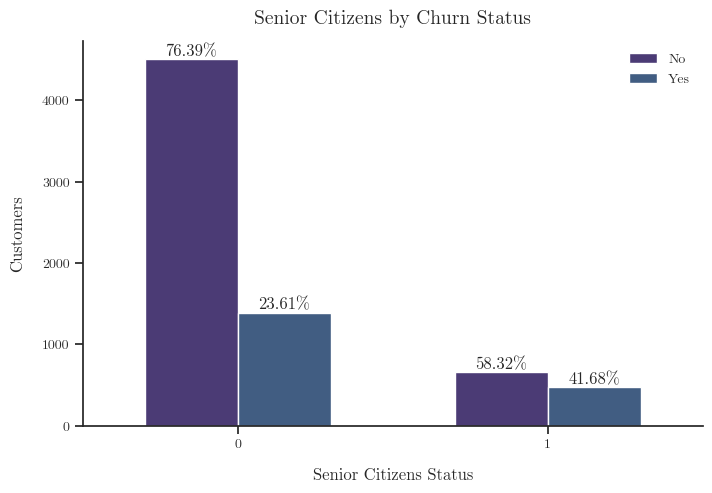

In [16]:
fig, ax = plt.subplots()

sns.countplot(
	data=telco_churn,
	x='SeniorCitizen',
	hue='Churn',
	width=0.6,
)

sns.despine()

ax.set_title('Senior Citizens by Churn Status')

ax.set_xlabel('Senior Citizens Status')
ax.set_ylabel('Customers')

ax.legend(frameon=False)

add_normalized_percentage_labels(ax, 2)

plt.show()

## Technical Support vs Churn

Question:
Does technical support reduce churn?

Goal:
Analyze whether customers subscribed to technical support services are less likely to churn.

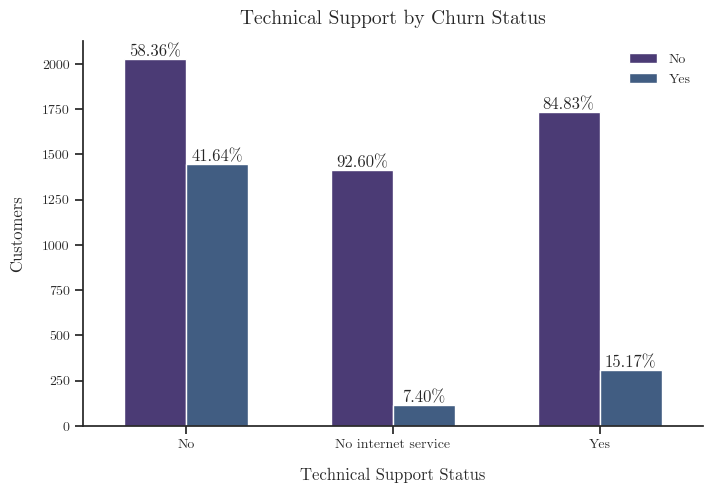

In [17]:
fig, ax = plt.subplots()

sns.countplot(
	data=telco_churn,
	x='TechSupport',
	hue='Churn',
	width=0.6,
)

sns.despine()

ax.set_title('Technical Support by Churn Status')

ax.set_xlabel('Technical Support Status')
ax.set_ylabel('Customers')

ax.legend(frameon=False)

add_normalized_percentage_labels(ax, 2)

plt.show()

## Correlation Between Numerical Features

Question:
How strongly are numerical features correlated?

Goal:
Identify potential linear relationships and redundant numerical features.

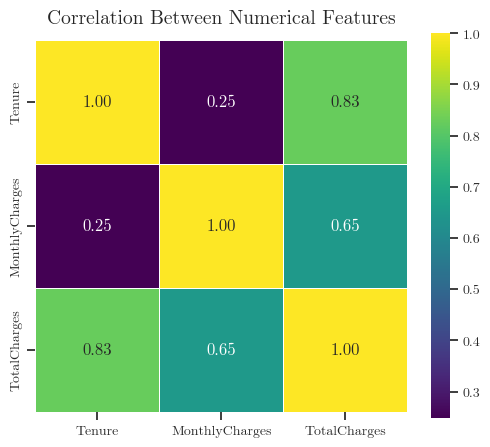

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))

numerical_features = telco_churn.loc[
	:, ['Tenure', 'MonthlyCharges', 'TotalCharges']
]

correlation_matrix = numerical_features.corr()

sns.heatmap(
	correlation_matrix,
	annot=True,
	cmap='viridis',
	fmt='.2f',
	linewidths=0.5,
	square=True,
	ax=ax,
)

ax.set_title('Correlation Between Numerical Features')

plt.show()

## Tenure vs Total Charges Relationship

Question:
How does customer tenure affect accumulated charges?

Goal:
Analyze the relationship between customer lifetime duration and total accumulated spending.

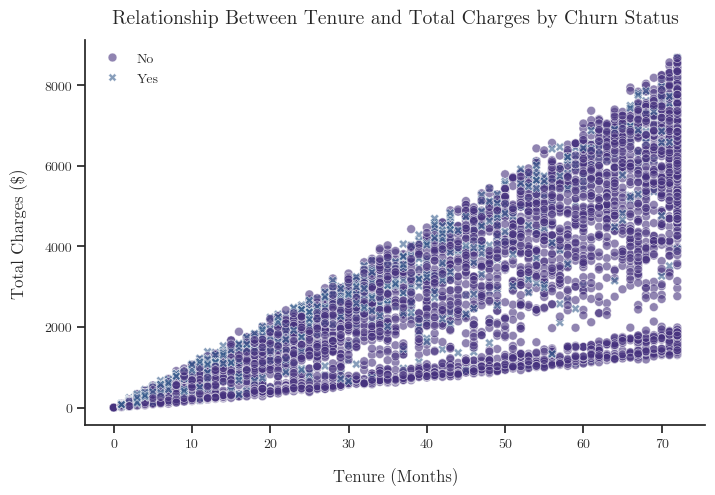

In [19]:
fig, ax = plt.subplots()

sns.scatterplot(
	data=telco_churn,
	x='Tenure',
	y='TotalCharges',
	hue='Churn',
	style='Churn',
	s=40,
	alpha=0.6,
)

sns.despine()

ax.set_title('Relationship Between Tenure and Total Charges by Churn Status')

ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Total Charges ($)')

ax.legend(frameon=False)

plt.show()